# Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters

In [2]:
wd = os.getcwd()
data_path = wd + "\\asian\\ASIAN.DAT"

save_path = wd + "\\prep_data\\data_"

# Load data

In [3]:
# Fixed columm width specification
colspecs = [
    (0, 4),   # ChildID
    (4, 7),   # Age
    (7, 12),  # Weight
    (12, 16), # BirthWeight
    (16, 17)  # Gender
]

column_names = ["ChildID", "Age", "Weight", "BirthWeight", "Gender"]

# data load
df = pd.read_fwf(data_path, colspecs=colspecs, names=column_names)

df.head()

,ChildID,Age,Weight,BirthWeight,Gender
0,2,377.0,10262.0,3360.0,2.0
1,2,825.0,14500.0,3360.0,2.0
2,3,54.0,4053.0,3310.0,2.0
3,3,242.0,8136.0,3310.0,2.0
4,3,377.0,9752.0,3310.0,2.0
...,...,...,...,...,...
1568,5003,846.0,17300.0,2760.0,2.0
1569,5016,50.0,4930.0,3525.0,2.0
1570,5016,249.0,9780.0,3525.0,2.0
1571,5020,830.0,13600.0,3300.0,2.0


# Exploratory analysis

In [4]:
df_count = df.groupby(["ChildID"]).count().reset_index()

df_count["NObs"] = df_count["Age"]
df_count = df_count[["ChildID", "NObs"]]
[print(i, ":", len(df_count[df_count["NObs"] == i])) for i in np.unique(df_count["NObs"])]

0 : 1
1 : 91
2 : 141
3 : 169
4 : 143
5 : 24


[None, None, None, None, None, None]

In [5]:
df = pd.merge(df,
              df_count,
              on = "ChildID", how = "left")
df

,ChildID,Age,Weight,BirthWeight,Gender,NObs
0,2,377.0,10262.0,3360.0,2.0,2
1,2,825.0,14500.0,3360.0,2.0,2
2,3,54.0,4053.0,3310.0,2.0,4
3,3,242.0,8136.0,3310.0,2.0,4
4,3,377.0,9752.0,3310.0,2.0,4
...,...,...,...,...,...,...
1568,5003,846.0,17300.0,2760.0,2.0,4
1569,5016,50.0,4930.0,3525.0,2.0,2
1570,5016,249.0,9780.0,3525.0,2.0,2
1571,5020,830.0,13600.0,3300.0,2.0,1


## Excluding NA observations

In [6]:
# Observe the one strange observation with NObs = 0
display(df.query("NObs == 0"))
df.query("NObs == 0")["ChildID"].iloc[0]

,ChildID,Age,Weight,BirthWeight,Gender,NObs
1572,,NaN,NaN,NaN,NaN,0


'\x1a'

In [7]:
print(len(df))
df = df[df["ChildID"] != '\x1a']
print(len(df))

1573
1572


In [8]:
df.isnull().sum()

# No more NA values are present

ChildID        0
Age            0
Weight         0
BirthWeight    0
Gender         0
NObs           0
dtype: int64

In [9]:
# df.query("NObs >=2").count()

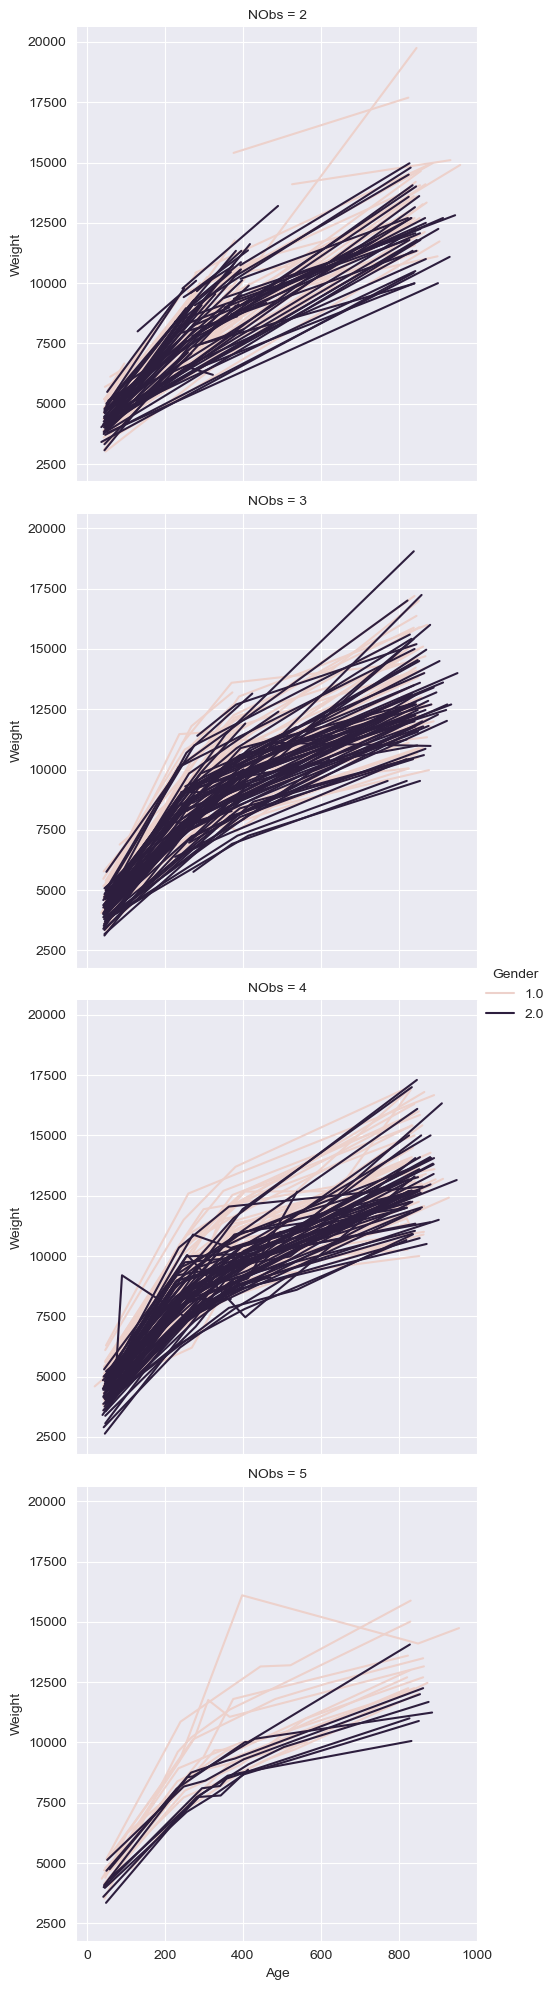

In [10]:
sns.relplot(
    x = "Age",
    y = "Weight",
    data = df.query("NObs >=2"), # 1481
    kind = "line",
    estimator = None,
    units = "ChildID",
    row = "NObs",
    hue = "Gender"
    
)

## Ideas so far:

- It seems that using logarithm of the age may be a good idea
- We might rescale other covariates to avoid big numbers for numerical stability
- We might include the birth weight as target variable values at the age 0. Then if we take logarithm, we first add +1 to all age values.


## Rahul
- Just for numerical stabalization we can also put log on weight, or any other down scaling transformation eg Standardization, Normalization.
also these tranformations make the relation pretty linear.

In [11]:
print([df['Age'].max(), df['Age'].min()])
print([df['Weight'].max(), df['Weight'].min()])

[957.0, 20.0]
[19750.0, 2635.0]


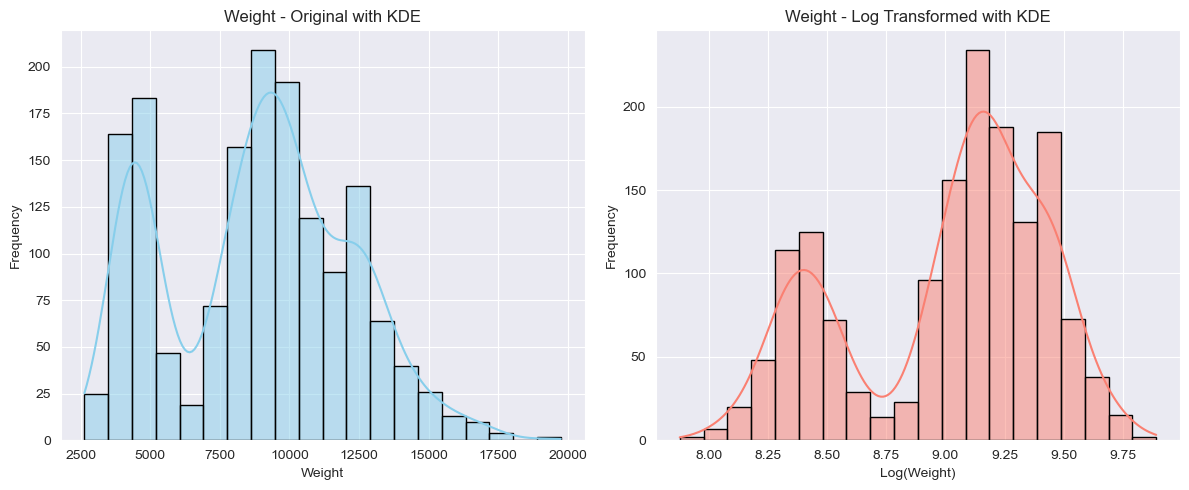

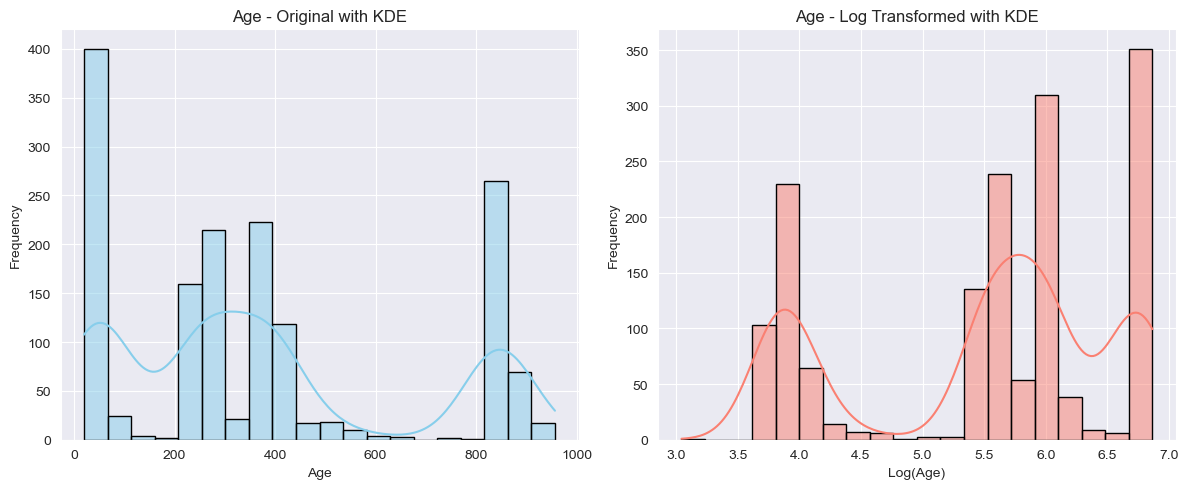

In [12]:
columns = ['Weight', 'Age']

for col in columns:
    plt.figure(figsize=(12, 5))
    
    # Original histogram + KDE
    plt.subplot(1, 2, 1)
    sns.histplot(df[col].dropna(), bins=20, kde=True, color='skyblue', edgecolor='black')
    plt.title(f'{col} - Original with KDE')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    
    # Log-transformed histogram + KDE
    plt.subplot(1, 2, 2)
    sns.histplot(np.log(df[col].dropna() + 1), bins=20, kde=True, color='salmon', edgecolor='black')
    plt.title(f'{col} - Log Transformed with KDE')
    plt.xlabel(f'Log({col})')
    plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()


# This does not make any much difference.

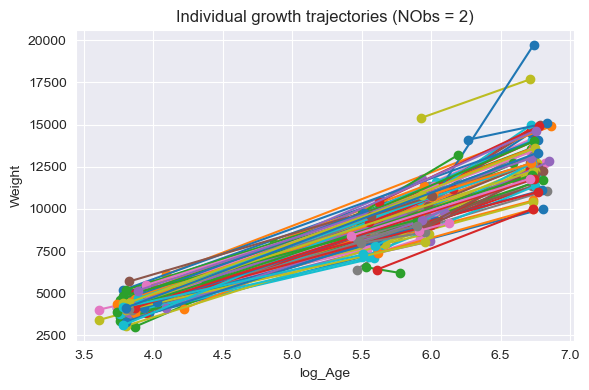

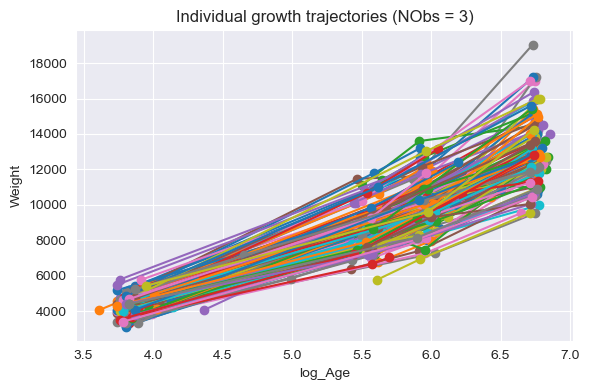

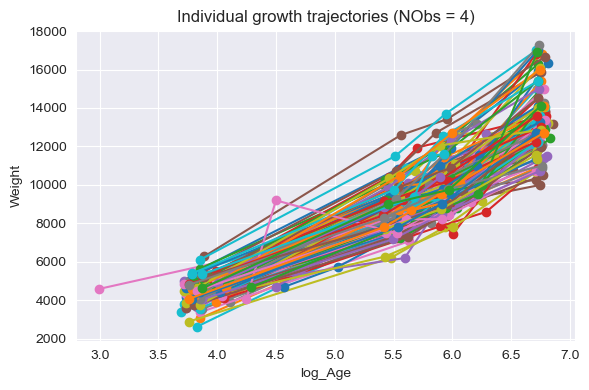

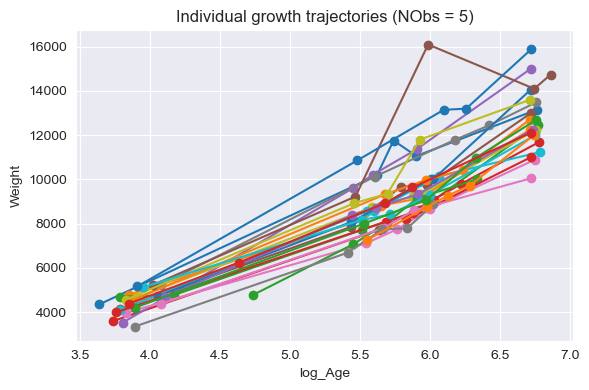

In [13]:
nobs_values = [2, 3, 4, 5]

for n in nobs_values:
    plt.figure(figsize=(6, 4))
    
    # Group by ChildID for the specific NObs
    for cid, g in df.query(f"NObs == {n}").groupby("ChildID"):
        plt.plot(np.log(g['Age']), g['Weight'], marker='o', linestyle='-')
    
    plt.xlabel("log_Age")
    plt.ylabel("Weight")
    plt.title(f"Individual growth trajectories (NObs = {n})")
    plt.tight_layout()
    plt.show()

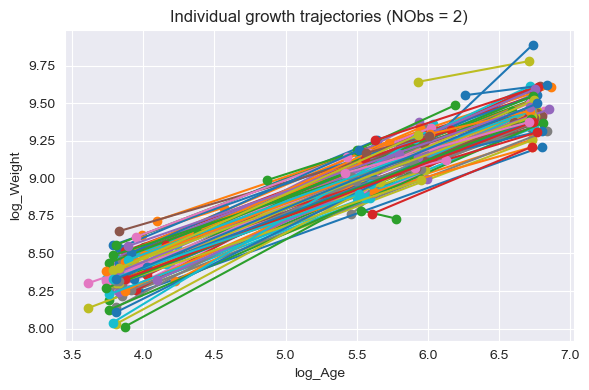

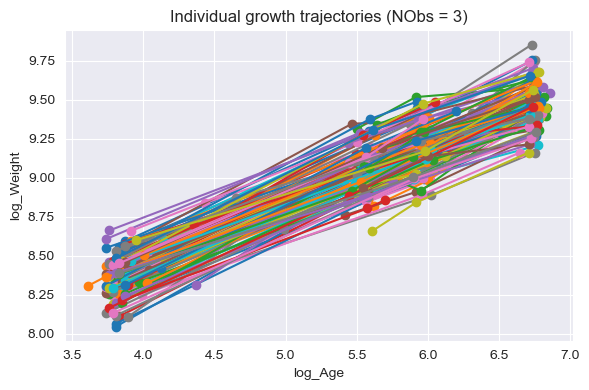

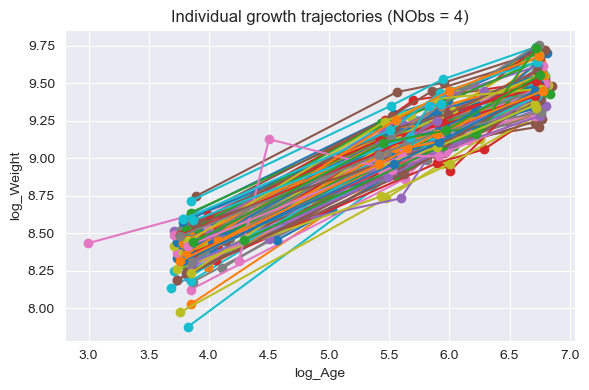

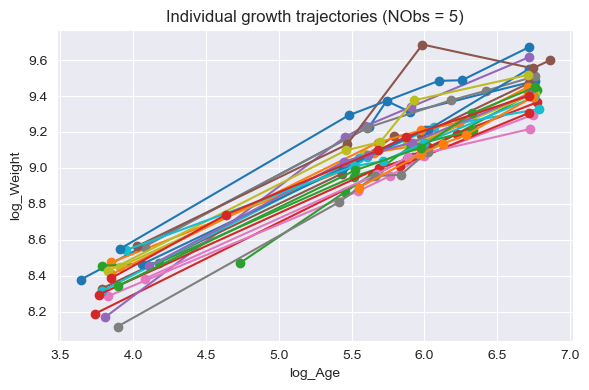

In [14]:
nobs_values = [2, 3, 4, 5]

for n in nobs_values:
    plt.figure(figsize=(6, 4))
    
    # Group by ChildID for the specific NObs
    for cid, g in df.query(f"NObs == {n}").groupby("ChildID"):
        plt.plot(np.log(g['Age']), np.log(g['Weight']), marker='o', linestyle='-')
    
    plt.xlabel("log_Age")
    plt.ylabel("log_Weight")
    plt.title(f"Individual growth trajectories (NObs = {n})")
    plt.tight_layout()
    plt.show()


# Preparation

### Birthweight into target variable at start

In [16]:
# Data set of BirthWeight at age 0
df_age0 = df.copy()[['ChildID', 'BirthWeight', 'Gender', "NObs"]]
df_age0['Age'] = 0
df_age0['Weight'] = df_age0['BirthWeight']
df_age0.drop_duplicates(inplace = True)

In [17]:
# row-wise concatenation
df_w0 = pd.concat([df_age0[["ChildID", "Age", "Weight", "Gender", "NObs"]],
                   df[["ChildID", "Age", "Weight", "Gender", "NObs"]]])
df_w0["NObs"]+=1

df_w0

,ChildID,Age,Weight,Gender,NObs
0,2,0.0,3360.0,2.0,3
2,3,0.0,3310.0,2.0,5
6,22,0.0,2710.0,2.0,5
10,23,0.0,3330.0,2.0,2
11,42,0.0,3370.0,1.0,2
...,...,...,...,...,...
1567,5003,376.0,11570.0,2.0,5
1568,5003,846.0,17300.0,2.0,5
1569,5016,50.0,4930.0,2.0,3
1570,5016,249.0,9780.0,2.0,3


### Logarithm of age variable

C:\Users\Admin\AppData\Local\Temp\ipykernel_2564\2752351950.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["log_Age"] = np.log(df["Age"])


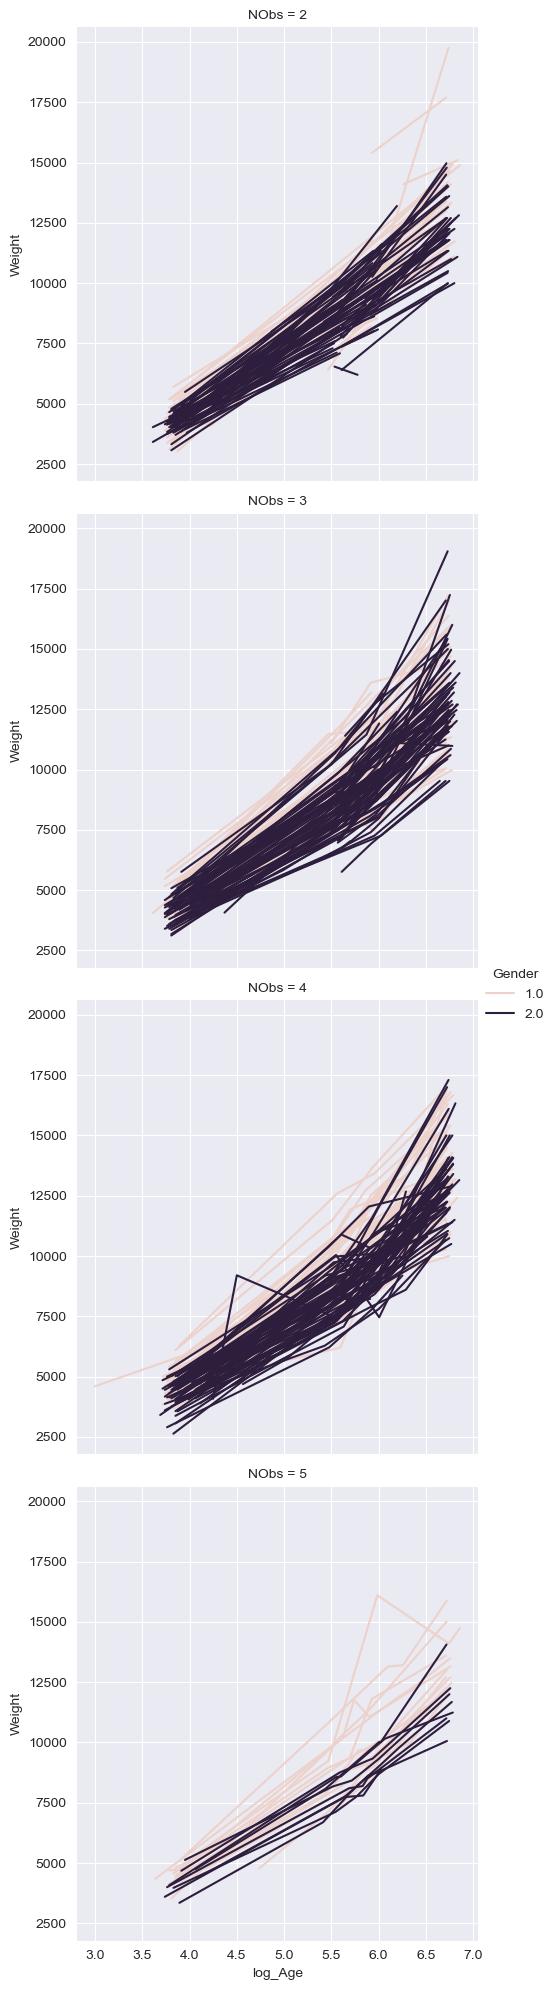

In [18]:
df["log_Age"] = np.log(df["Age"])

sns.relplot(
    x = "log_Age",
    y = "Weight",
    data = df.query("NObs >=2"),
    kind = "line",
    estimator = None,
    units = "ChildID",
    hue = "Gender",
    row = "NObs"
)

In [19]:
df_w0["log_Age"] = np.log(df_w0["Age"] + 1)

### Rescaling?

## Divide into separate datasets wrt number of observations ???

In [20]:
df_list = []
df_w0_list = []
for i in range(1, 6):
    id_list = list(np.unique(df[df["NObs"] == i]["ChildID"]))

    df_list.append(df.loc[df["ChildID"].isin(id_list)])
    df_w0_list.append(df_w0.loc[df_w0["ChildID"].isin(id_list)])

In [21]:
df_w0

,ChildID,Age,Weight,Gender,NObs,log_Age
0,2,0.0,3360.0,2.0,3,0.000000
2,3,0.0,3310.0,2.0,5,0.000000
6,22,0.0,2710.0,2.0,5,0.000000
10,23,0.0,3330.0,2.0,2,0.000000
11,42,0.0,3370.0,1.0,2,0.000000
...,...,...,...,...,...,...
1567,5003,376.0,11570.0,2.0,5,5.932245
1568,5003,846.0,17300.0,2.0,5,6.741701
1569,5016,50.0,4930.0,2.0,3,3.931826
1570,5016,249.0,9780.0,2.0,3,5.521461


In [22]:
df1, df2, df3, df4, df5 = df_list
df_w01, df_w0_2, df_w03, df_w04, df_w05 = df_w0_list

# Save data

In [26]:
for i in range(0, len(df_list)):
    df_list[i].to_csv(f"{save_path}{i+1}_obs_wide.csv")
    df_w0_list[i].to_csv(f"{save_path}{i+1}_obs_long.csv")

In [25]:
df_list


[     ChildID    Age   Weight  BirthWeight  Gender  NObs   log_Age
 10        23  243.0   8000.0       3330.0     2.0     1  5.493061
 11        42   67.0   5300.0       3370.0     1.0     1  4.204693
 28       103   44.0   4900.0       3300.0     1.0     1  3.784190
 29       104  860.0  12700.0       3200.0     2.0     1  6.756932
 49       146   48.0   4200.0       3345.0     2.0     1  3.871201
 ...      ...    ...      ...          ...     ...   ...       ...
 1417    4628  458.0  10000.0       3185.0     2.0     1  6.126869
 1446    4703  864.0  13600.0       2860.0     1.0     1  6.761573
 1447    4717   42.0   4740.0       3610.0     2.0     1  3.737670
 1477    4803  840.0  12250.0       2710.0     2.0     1  6.733402
 1571    5020  830.0  13600.0       3300.0     2.0     1  6.721426
 
 [91 rows x 7 columns],
      ChildID    Age   Weight  BirthWeight  Gender  NObs   log_Age
 0          2  377.0  10262.0       3360.0     2.0     2  5.932245
 1          2  825.0  14500.0       

## Model formula in R
log(Weight) ~ 1 + log(Age) + (1 + log(Age)|ChildID)
- fixed effects and random effects for intercept and slope both.
- However, I think the random slope effect will hardly change the fitting. So maybe we can try fitting both then see affter evalution and also we can present this in the presentation.